In [1]:
num_epochs = 10
batch_size = 32
best_accuracy = 0

In [2]:
import torch
import torch.nn as nn
import numpy as np
import os
import pandas as pd
import dask.dataframe as dd
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torch.nn.functional as F
from IPython.display import clear_output
import time
import re
import matplotlib.pyplot as plt
from datetime import datetime
import math

c:\Users\timy3\anaconda3\envs\pytorch\Lib\site-packages\dask\dataframe\_pyarrow_compat.py:23: UserWarning: You are using pyarrow version 13.0.0 which is known to be insecure. See https://www.cve.org/CVERecord?id=CVE-2023-47248 for further details. Please upgrade to pyarrow>=14.0.1 or install pyarrow-hotfix to patch your current version.
  warnings.warn(


In [3]:
class MyCNN(nn.Module):
    def __init__(self, num_layers = 15, input_features=34, input_channels=29, output_features=34):
        super(MyCNN, self).__init__()
        
        self.conv_layers = nn.ModuleList()

        self.conv_layers.append(nn.Conv1d(in_channels=input_channels, out_channels=512, kernel_size=3, padding=1))
        
        for _ in range(1, num_layers - 1):
            self.conv_layers.append(
                nn.Sequential(
                    nn.Conv1d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
                    nn.BatchNorm1d(512),
                    nn.LeakyReLU(0.01)
                    )
            )
        
        self.conv_layers.append(nn.Conv1d(in_channels=512, out_channels=1, kernel_size=1, padding=0))
        
        self.activation = nn.LeakyReLU(negative_slope=0.01)

        self.fc = nn.Linear(input_features, output_features)
    def forward(self, x):
        x = x.squeeze(1)
        x = x.permute(0, 2, 1)

        for i, conv in enumerate(self.conv_layers):
            if(i < len(self.conv_layers) - 1):
                x = self.activation(conv(x))
            else:
                x = conv(x)
                
        x = x.squeeze(1)
        x = self.fc(x)
        print("x.shape:",x.shape)
        
        return x

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [5]:
input_folder = "E:\專題\discard_model\DiscardModel_15_512"
models_path = []
time_pattern = re.compile(r'^CNN_discard_model_\d{8}_\d{6}\.pth$')

for filename in os.listdir(input_folder):
    if time_pattern.match(filename):
        txt_path = os.path.join(input_folder, filename)
        models_path.append(txt_path)

print(f"成功載入了 {len(models_path)} 個時間格式的模型：")
for path in models_path:
    print(path)

成功載入了 66 個時間格式的模型：
E:\專題\discard_model\DiscardModel_15_512\CNN_discard_model_20251016_154303.pth
E:\專題\discard_model\DiscardModel_15_512\CNN_discard_model_20251016_184409.pth
E:\專題\discard_model\DiscardModel_15_512\CNN_discard_model_20251016_214618.pth
E:\專題\discard_model\DiscardModel_15_512\CNN_discard_model_20251017_004756.pth
E:\專題\discard_model\DiscardModel_15_512\CNN_discard_model_20251017_034931.pth
E:\專題\discard_model\DiscardModel_15_512\CNN_discard_model_20251017_065017.pth
E:\專題\discard_model\DiscardModel_15_512\CNN_discard_model_20251017_095149.pth
E:\專題\discard_model\DiscardModel_15_512\CNN_discard_model_20251017_125344.pth
E:\專題\discard_model\DiscardModel_15_512\CNN_discard_model_20251017_155519.pth
E:\專題\discard_model\DiscardModel_15_512\CNN_discard_model_20251017_185522.pth
E:\專題\discard_model\DiscardModel_15_512\CNN_discard_model_20251017_215746.pth
E:\專題\discard_model\DiscardModel_15_512\CNN_discard_model_20251018_005836.pth
E:\專題\discard_model\DiscardModel_15_512\CNN_d

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\timy3\AppData\Local\Temp\ipykernel_2764\1167705588.py:1: SyntaxWarning: invalid escape sequence '\d'
  input_folder = "E:\專題\discard_model\DiscardModel_15_512"


In [6]:
class MyDataset(Dataset):
    def __init__(self, file_path, chunk_size):
        self.file_path = file_path
        self.chunk_size = chunk_size
        
        self.columns = pd.read_csv(self.file_path, nrows=0).columns.str.strip().str.replace('\xa0', ' ').tolist()
        self.train_columns = [col for col in self.columns if col != 'Discard']  # 排除 'discard' 欄位
        self.num_samples = sum(1 for _ in open(self.file_path, encoding='utf-8')) - 1  # 計算總樣本數
        
    def __getitem__(self, idx):
        chunk_start = idx // self.chunk_size * self.chunk_size
        df = pd.read_csv(self.file_path, skiprows=chunk_start + 1, nrows=self.chunk_size, header=None, encoding='utf-8')  # 跳過標題和之前的行

        df.columns = self.columns
        
        if 'Discard' not in df.columns:
            raise KeyError(f"Chunk starting at row {chunk_start + 1} does not contain 'Discard' column.")
        
            
        sample_idx = idx % self.chunk_size
        
        train_data = df[self.train_columns].iloc[sample_idx].values.astype("float32")
        train_data = train_data.reshape(34, 29)
        
        value_data = df['Discard'].iloc[sample_idx]  # 提取 'Discard' 欄位
        
        return torch.tensor(train_data, dtype=torch.float32), torch.tensor(value_data, dtype=torch.long)
        
    def __len__(self):
        return self.num_samples

In [7]:
"""
讀取csv
"""
file_path = 'E:/專題/data/2022/DiscardData.csv'
dataset = MyDataset(file_path, chunk_size=50000)  # 每次只加載 50000 行
test_dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

In [ ]:
MODEL_BATCH_SIZE = 7
VALIDATION_TIME_LIMIT = 30 * 60

num_total_models = len(models_path)
num_batches = math.ceil(num_total_models / MODEL_BATCH_SIZE)
loss_criterion  = nn.CrossEntropyLoss()

all_models_final_results = {}

for batch_num in range(num_batches):
    start_index = batch_num * MODEL_BATCH_SIZE
    end_index = min((batch_num + 1) * MODEL_BATCH_SIZE, num_total_models)
    current_batch_paths = models_path[start_index:end_index]

    model_list = [torch.load(p, map_location=device, weights_only=False).to(device).eval() for p in current_batch_paths]
    num_models_in_this_batch = len(model_list)

    correct_list = [0] * num_models_in_this_batch
    loss_list = [0.0] * num_models_in_this_batch
    total_samples = 0

    with torch.no_grad():
        start_time_for_this_batch = time.time()
        for data_batch_num, (train_data, value_data) in enumerate(test_dataloader):
            torch.autograd.set_detect_anomaly(True)

            channel1_tensor = train_data.unsqueeze(1).to(device)
            value_data = value_data.to(device).long()
            batch_size = value_data.size(0)
            total_samples += batch_size

            rows = []

            for i, model in enumerate(model_list):
            
                output = model(channel1_tensor).float()
                probabilities = F.softmax(output, dim=1)
                predicted_labels = torch.argmax(probabilities, dim=1)
                correct_predictions = (predicted_labels == value_data).sum().item()
                correct_list[i] += correct_predictions

                loss = loss_criterion(output, value_data)
                loss_list[i] += loss.item() * batch_size

                accuracy = (correct_predictions / batch_size) * 100
                total_accuracy = (correct_list[i] / total_samples) * 100

                model_name = os.path.basename(current_batch_paths[i])

                rows.append({
                    "Model": model_name,
                    "Cur Acc (%)": f"{accuracy:.2f}",
                    "Total Acc (%)": f"{total_accuracy:.2f}",
                    "Loss": f"{loss.item():.4f}",
                })
            
            clear_output(wait=True)
            df = pd.DataFrame(rows)
            display(df)

            elapsed_time = time.time() - start_time_for_this_batch
            if elapsed_time > VALIDATION_TIME_LIMIT:
                print(f"\n--- ⏱️ 時間到 (已執行 {elapsed_time:.1f} 秒) ---")
                print(f"已完成 {data_batch_num + 1} / {len(test_dataloader)} 個資料批次。")
                print("正在強制跳至下一輪模型...")
                break



    for i in range(num_models_in_this_batch):
        model_name = os.path.basename(current_batch_paths[i])
        if total_samples > 0:
            final_accuracy = (correct_list[i] / total_samples) * 100
            final_avg_loss = loss_list[i] / total_samples
            
            print(f"Model: {model_name} | Final Acc: {final_accuracy:.4f}% | Avg Loss: {final_avg_loss:.4f}")
            
            all_models_final_results[model_name] = {
                "accuracy": final_accuracy,
                "loss": final_avg_loss
            }
        else:
            print(f"Model: {model_name} | No validation data processed.")
            all_models_final_results[model_name] = {
                "accuracy": 0,
                "loss": 0
            }

    del model_list # 刪除模型列表
    del model # 刪除迴圈中殘留的最後一個模型變數
    
    # 如果使用 GPU，強制 PyTorch 釋放快取的 VRAM
    if device.type == 'cuda':
        torch.cuda.empty_cache()
        print("CUDA cache 已清除。")

results_df = pd.DataFrame.from_dict(all_models_final_results, orient='index')
results_df = results_df.sort_values(by="accuracy", ascending=False)

try:
    results_df.to_csv("validation_results.csv")
    print("\n--- ✅ 成功將 63 筆完整結果儲存到 'validation_results.csv' ---")
    print("   (下次 Kernel 若崩潰，可直接從 CSV 讀取，不需重跑)")
except Exception as e:
    print(f"\n--- ❌ 儲存 CSV 時出錯: {e} ---")

#    設定 pandas 顯示所有列 (None = 無限制)
pd.set_option('display.max_rows', None) 

# --- 修正結束 ---


print("\n最終驗證結果總覽 (完整 63 筆):")
display(results_df) # <--- 現在這行會顯示完整 63 筆，不會有 ...

# 找出最好的模型
if not results_df.empty:
    best_model_name = results_df.index[0]
    best_accuracy = results_df.iloc[0]['accuracy']
    print(f"\n🎉 表現最好的模型是: {best_model_name} (準確率: {best_accuracy:.4f}%)")



,Model,Cur Acc (%),Total Acc (%),Loss
0,CNN_discard_model_20251024_134741.pth,53.12,42.81,1.7094
1,CNN_discard_model_20251024_164820.pth,62.50,44.06,1.6035
2,CNN_discard_model_20251024_194933.pth,56.25,45.00,1.4307



--- ⏱️ 時間到 (已執行 1836.4 秒) ---
已完成 20 / 3638 個資料批次。
正在強制跳至下一輪模型...
Model: CNN_discard_model_20251024_134741.pth | Final Acc: 42.8125% | Avg Loss: 2.0953
Model: CNN_discard_model_20251024_164820.pth | Final Acc: 44.0625% | Avg Loss: 2.0295
Model: CNN_discard_model_20251024_194933.pth | Final Acc: 45.0000% | Avg Loss: 1.9681
CUDA cache 已清除。

--- ✅ 成功將 63 筆完整結果儲存到 'validation_results.csv' ---
   (下次 Kernel 若崩潰，可直接從 CSV 讀取，不需重跑)

最終驗證結果總覽 (完整 63 筆):


,accuracy,loss
CNN_discard_model_20251023_224127.pth,45.937500,2.011577
CNN_discard_model_20251024_194933.pth,45.000000,1.968108
CNN_discard_model_20251023_133801.pth,44.687500,2.055631
CNN_discard_model_20251022_223328.pth,44.687500,2.033252
CNN_discard_model_20251024_044424.pth,44.218750,2.126723
CNN_discard_model_20251023_194010.pth,44.218750,2.027914
CNN_discard_model_20251023_103701.pth,44.218750,2.066408
CNN_discard_model_20251024_164820.pth,44.062500,2.029541
CNN_discard_model_20251022_193249.pth,43.593750,2.082897
CNN_discard_model_20251024_074525.pth,43.593750,2.031207



🎉 表現最好的模型是: CNN_discard_model_20251023_224127.pth (準確率: 45.9375%)


: 

In [ ]:

# --- 10. [新增] 繪製結果圖表 ---
print("\n\n--- 📈 正在繪製結果圖表 ---")

# (我們需要 re 模組來解析檔名)
# 建立一個正規表示式，用 ( ) 來 "捕獲" 日期和時間
# 捕獲組 1: (\d{8}) -> 8 位數字 (日期)
# 捕獲組 2: (\d{6}) -> 6 位數字 (時間)
plot_pattern = re.compile(r'CNN_discard_model_(\d{8})_(\d{6})\.pth$')

parsed_results = [] # 用來儲存 (datetime 物件, accuracy, loss)

# 1. 遍歷所有儲存的結果
for model_name, metrics in all_models_final_results.items():
    match = plot_pattern.search(model_name)
    
    if match:
        # match.group(1) 是 '20251024', match.group(2) 是 '104657'
        timestamp_str = match.group(1) + match.group(2)
        
        try:
            # 將 '20251024104657' 轉換為 Python 的 datetime 物件
            dt = datetime.strptime(timestamp_str, '%Y%m%d%H%M%S')
            
            # 將 (時間, 準確率, 損失) 加入列表
            parsed_results.append((dt, metrics['accuracy'], metrics['loss']))
        except ValueError:
            print(f"解析檔名 {model_name} 的時間時出錯。")
    else:
        print(f"檔名 {model_name} 格式不符，跳過繪圖。")

# 2. 檢查是否有可繪製的資料
if not parsed_results:
    print("沒有找到可繪製的有效模型資料。")
else:
    # 3. (重要) 根據時間 (list 中 tuple 的第一個元素) 進行排序
    parsed_results.sort(key=lambda x: x[0])

    # 4. 準備 x 軸 (相對小時數) 和 y 軸 (準確率, 損失)
    
    # 取得第一個模型 (最早的) 時間作為基準點
    start_datetime = parsed_results[0][0] 
    
    relative_hours = [] # x 軸
    accuracies = []     # y 軸 1
    losses = []         # y 軸 2

    for dt, acc, loss in parsed_results:
        # 計算與第一個模型的時間差
        time_delta = dt - start_datetime
        
        # 將時間差轉換為小時
        hours = time_delta.total_seconds() / 3600.0
        
        relative_hours.append(hours)
        accuracies.append(acc)
        losses.append(loss)

    # 5. 繪製第一張圖：時間 vs 準確率
    plt.figure(figsize=(10, 5))
    plt.plot(relative_hours, accuracies, marker='o', linestyle='-', label='Accuracy')
    plt.title('Validation Accuracy vs. Training Time')
    plt.xlabel('Training Time (Hours)')
    plt.ylabel('Validation Accuracy (%)')
    plt.grid(True)
    plt.legend()
    # 根據你的間隔 (3小時) 來設定 x 軸刻度，使其更易讀
    # 例如，如果總時數超過 24 小時，每 6 小時一個刻度
    max_hours = max(relative_hours) if relative_hours else 1
    tick_spacing = 3 if max_hours < 24 else 6
    plt.xticks(range(0, int(max_hours) + tick_spacing, tick_spacing))
    plt.show()

    # 6. 繪製第二張圖：時間 vs 損失
    plt.figure(figsize=(10, 5))
    plt.plot(relative_hours, losses, marker='o', linestyle='-', color='r', label='Loss')
    plt.title('Validation Loss vs. Training Time')
    plt.xlabel('Training Time (Hours)')
    plt.ylabel('Average Validation Loss')
    plt.grid(True)
    plt.legend()
    plt.xticks(range(0, int(max_hours) + tick_spacing, tick_spacing))
    plt.show()



--- 📈 正在繪製結果圖表 ---


In [1]:
import pandas as pd
import re
from IPython.display import display # 用於顯示

# --- 1. 從 CSV 檔案讀取你上次儲存的結果 ---
print("--- 正在從 'validation_results.csv' 讀取資料... ---")
try:
    # index_col=0 告訴 pandas，第一欄 (模型名稱) 應該作為索引 (index)
    results_df = pd.read_csv("validation_results.csv", index_col=0)
    
    print("✅ 資料讀取成功。")
    print(" (原始排序，根據 'accuracy' 欄位):")
    display(results_df.head()) # 顯示前 5 行，確認一下

except FileNotFoundError:
    print("❌ 錯誤: 找不到 'validation_results.csv' 檔案。")
    print("   (請確保這個 CSV 檔和你的 .ipynb 筆記本在同一個資料夾)")
except Exception as e:
    print(f"❌ 讀取 CSV 時出錯: {e}")
    # 如果出錯，後面的程式碼會停止

# --- 2. 建立一個「可排序的時間字串」的新欄位 ---
# (這段程式碼和上次給你的完全一樣)

# 定義用來抓取時間的規則
time_pattern = re.compile(r'CNN_discard_model_(\d{8})_(\d{6})\.pth$')

def extract_timestamp(model_name):
    """ 從模型名稱中抓出 'YYYYMMDDHHMMSS' 格式的字串 """
    match = time_pattern.search(str(model_name))
    if match:
        # 合併為 '20251023164243'，這個字串可以直接排序
        return match.group(1) + match.group(2)
    else:
        # 如果格式不符，給它一個 '0'
        return '0' 

# 'results_df.index' 就是你的模型名稱欄
results_df['sortable_time'] = results_df.index.to_series().apply(extract_timestamp)

# --- 3. 根據這個新欄位排序 ---
# ascending=True 表示從最早的排到最新的
results_df_sorted_by_time = results_df.sort_values(by='sortable_time', ascending=True)

# --- 4. (可選) 刪除我們剛剛多加的輔助欄位，讓表格乾淨一點 ---
results_df_sorted_by_time = results_df_sorted_by_time.drop(columns=['sortable_time'])

# --- 5. 顯示按時間排序的結果 ---
print("\n\n--- 🔔 根據模型儲存時間排序 (從早到晚) ---")
# 設定 pandas 顯示所有列 (None = 無限制)，確保你不會看到 '...'
pd.set_option('display.max_rows', None) 
display(results_df_sorted_by_time)

--- 正在從 'validation_results.csv' 讀取資料... ---
✅ 資料讀取成功。
 (原始排序，根據 'accuracy' 欄位):


,accuracy,loss
CNN_discard_model_20251023_224127.pth,45.93750,2.011577
CNN_discard_model_20251024_194933.pth,45.00000,1.968108
CNN_discard_model_20251023_133801.pth,44.68750,2.055631
CNN_discard_model_20251022_223328.pth,44.68750,2.033252
CNN_discard_model_20251024_044424.pth,44.21875,2.126723




--- 🔔 根據模型儲存時間排序 (從早到晚) ---


,accuracy,loss
CNN_discard_model_20251016_154303.pth,5.098684,3.443636
CNN_discard_model_20251016_184409.pth,11.677632,3.347440
CNN_discard_model_20251016_214618.pth,9.210526,3.359705
CNN_discard_model_20251017_004756.pth,15.460526,3.244706
CNN_discard_model_20251017_034931.pth,19.407895,3.127512
CNN_discard_model_20251017_065017.pth,18.092105,3.121526
CNN_discard_model_20251017_095149.pth,21.875000,3.004332
CNN_discard_model_20251017_125344.pth,20.468750,2.956220
CNN_discard_model_20251017_155519.pth,23.281250,2.913984
CNN_discard_model_20251017_185522.pth,26.250000,2.778150


--- 📈 正在準備繪圖資料... ---
基準時間 (0 小時): CNN_discard_model_20251016_154303.pth
✅ 繪圖資料準備完畢。

--- 正在繪製 [準確率] 圖表... ---


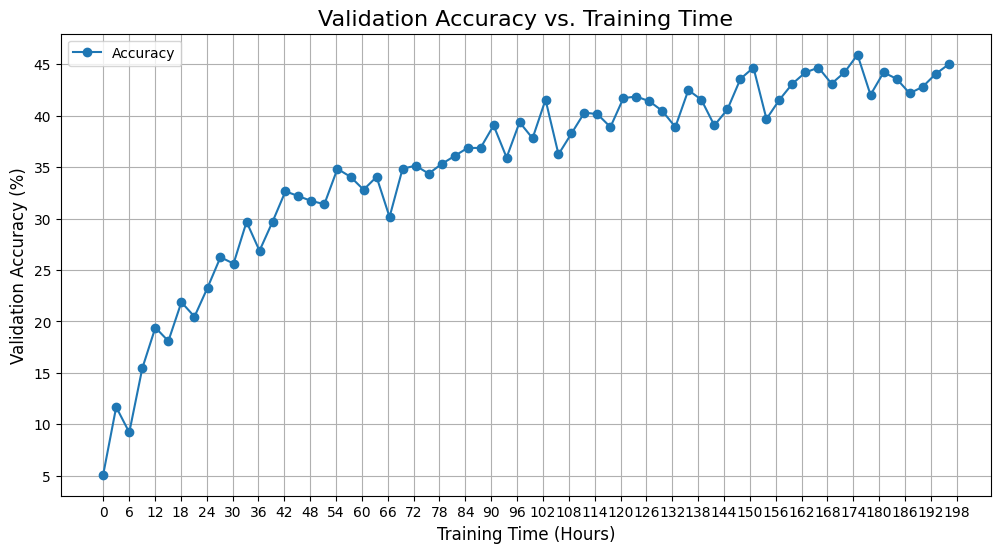


--- 正在繪製 [Loss] 圖表... ---


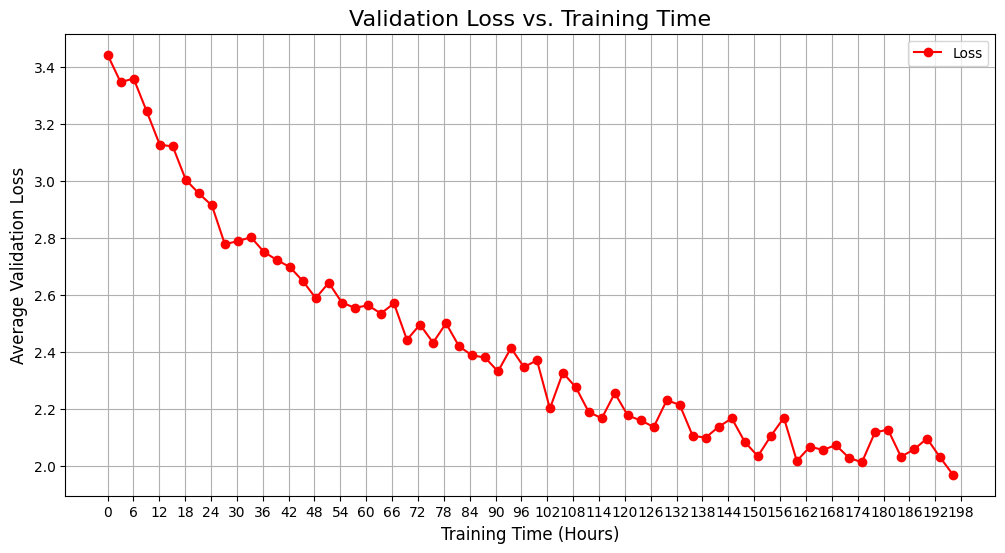


--- ✅ 繪圖全部完成 ---


In [2]:
import matplotlib.pyplot as plt
from datetime import datetime
import re
import pandas as pd # 確保 import

# (假設你上一個 cell 排序後的變數名稱是 results_df_sorted_by_time)
# (如果不是，請修改下面的變數名稱)

print("--- 📈 正在準備繪圖資料... ---")

# --- 1. 準備繪圖用的 X 軸和 Y 軸資料 ---

# 定義用來抓取時間的規則
time_pattern = re.compile(r'CNN_discard_model_(\d{8})_(\d{6})\.pth$')

relative_hours = [] # X 軸：相對訓練時數
accuracies = []     # Y 軸 1：準確率
losses = []         # Y 軸 2：損失

# 檢查 DataFrame 是否為空
if results_df_sorted_by_time.empty:
    print("!! 錯誤: DataFrame 是空的，無法繪圖。")
else:
    # 2. 找出基準時間 (第一個模型的時間)
    try:
        first_model_name = results_df_sorted_by_time.index[0]
        match = time_pattern.search(first_model_name)
        timestamp_str = match.group(1) + match.group(2)
        start_datetime = datetime.strptime(timestamp_str, '%Y%m%d%H%M%S')
        print(f"基準時間 (0 小時): {first_model_name}")
    except Exception as e:
        print(f"!! 錯誤: 解析第一個模型名稱時出錯: {e}")
        # 如果出錯，就無法繼續
        start_datetime = None

    if start_datetime:
        # 3. 遍歷排序好的 DataFrame，計算相對時數
        for model_name, row in results_df_sorted_by_time.iterrows():
            acc = row['accuracy']
            loss = row['loss']
            
            match = time_pattern.search(str(model_name))
            if match:
                # 解析目前模型的時間
                timestamp_str = match.group(1) + match.group(2)
                current_datetime = datetime.strptime(timestamp_str, '%Y%m%d%H%M%S')
                
                # 計算與第一個模型的時間差
                time_delta = current_datetime - start_datetime
                
                # 將時間差轉換為小時
                hours = time_delta.total_seconds() / 3600.0
                
                relative_hours.append(hours)
                accuracies.append(acc)
                losses.append(loss)
            else:
                print(f"檔名 {model_name} 格式不符，跳過。")
        
        print("✅ 繪圖資料準備完畢。")

        # --- 4. 繪製第一張圖：時間 vs 準確率 ---
        print("\n--- 正在繪製 [準確率] 圖表... ---")
        plt.figure(figsize=(12, 6)) # 圖表放大一點
        plt.plot(relative_hours, accuracies, marker='o', linestyle='-', label='Accuracy')
        plt.title('Validation Accuracy vs. Training Time', fontsize=16)
        plt.xlabel('Training Time (Hours)', fontsize=12)
        plt.ylabel('Validation Accuracy (%)', fontsize=12)
        plt.grid(True)
        plt.legend()
        
        # 根據你的間隔 (3小時) 來設定 x 軸刻度
        max_hours = max(relative_hours) if relative_hours else 1
        # 每 3 小時一個刻度，如果超過 24 小時，改為 6 小時
        tick_spacing = 3 if max_hours <= 24 else 6 
        plt.xticks(range(0, int(max_hours) + tick_spacing, tick_spacing))
        plt.show()

        # --- 5. 繪製第二張圖：時間 vs 損失 ---
        print("\n--- 正在繪製 [Loss] 圖表... ---")
        plt.figure(figsize=(12, 6))
        plt.plot(relative_hours, losses, marker='o', linestyle='-', color='r', label='Loss')
        plt.title('Validation Loss vs. Training Time', fontsize=16)
        plt.xlabel('Training Time (Hours)', fontsize=12)
        plt.ylabel('Average Validation Loss', fontsize=12)
        plt.grid(True)
        plt.legend()
        plt.xticks(range(0, int(max_hours) + tick_spacing, tick_spacing))
        plt.show()

        print("\n--- ✅ 繪圖全部完成 ---")